# Lecture 0 — Part 1
## One Financial Problem, Eight Generations of Intelligence

### From relationships to organized judgment

This notebook is the conceptual opening laboratory for **AI for Financial Practitioners**. Its purpose is not to tell a simplistic story in which every new technology makes everything before it obsolete. Instead, we hold one financial problem constant and solve it repeatedly with different generations of analytical intelligence. By doing so, we can see what genuinely changes as technology evolves: not simply predictive accuracy, but the kinds of questions a machine can address, the representations it can learn, the information it can consume, the explanations it can produce, and the degree of judgment that can be organized around a decision.

Our fixed problem is an investment-classification mandate. Imagine an institution examining a universe of 500 synthetic listed companies. For each company we observe financial and market characteristics such as revenue growth, EBITDA margin, return on invested capital, leverage, valuation, volatility, momentum, recurring revenue and cash generation. The institution wants to classify each company into one of six intuitive investment profiles: **Defensive, Quality, Growth, Value, Cyclical, or Distressed**.

The labels are less important than the controlled experiment. Every generation receives essentially the same economic world. We change the analytical mechanism. This allows us to ask a deeper question than “Which model is best?” We can ask: **What kind of problem can this generation of intelligence solve?**

We begin with statistics. Correlations, standardized variables and distance measures do not “understand” a company, but they describe relationships and similarities. They allow an analyst to say that two firms occupy similar positions in a measurable financial space. That is already a useful form of intelligence.

Econometrics adds an explicit probabilistic mapping between company characteristics and categories. A multinomial logistic model estimates the probability that a company belongs to each investment profile. The system moves from describing relationships to estimating conditional probabilities. Its coefficients also provide an interpretable connection between financial characteristics and classifications.

Classical machine learning changes the emphasis again. Decision trees and random forests need not impose a linear relationship. They can learn interactions and nonlinear rules from data. A company can be classified because several conditions occur together, even when no single coefficient captures the pattern.

Unsupervised learning asks a different question. Instead of being told the six categories, clustering algorithms examine the data and discover groupings. This distinction is fundamental. Intelligence can be predictive, but it can also be exploratory. A system may reveal a structure that the institution did not specify in advance.

Neural machine learning then learns nonlinear representations useful for multiclass classification. Rather than relying on manually specified decision rules, the network transforms inputs through hidden layers. The representation itself becomes part of what is learned.

An autoencoder pushes this idea further. Its primary task is not the investment label. It learns a compressed latent representation of the company universe by reconstructing the original information through a bottleneck. We can then inspect whether economically meaningful groupings emerge in that latent space. The analytical object has shifted from coefficients or rules toward learned representation.

Generative AI introduces another expansion. Financial practitioners do not live only in spreadsheets. They read company descriptions, management commentary, research notes, filings and qualitative evidence. A transformer-based language model can operate on an analyst-style company dossier and interpret its meaning. The machine can now combine quantitative facts expressed in language with qualitative context and produce a classification together with an explanation. This does not mean the LLM must outperform a random forest on a clean tabular benchmark. That would be the wrong lesson. Its importance is that the **problem space has expanded**.

Finally, we move from a single generative model to organized judgment. A company can be examined from multiple perspectives: fundamentals, valuation, risk and market behavior. Specialist agents can analyze the same dossier independently. A committee mechanism can preserve disagreement, synthesize evidence and produce a bounded classification. At this point the important innovation is no longer simply the model. It is the architecture around the model.

The progression can therefore be summarized as:

**relationships → coefficients → rules → discovered structure → learned representations → latent representations → meaning → organized judgment.**

Notice what this progression does **not** say. It does not say that statistics stops being useful when machine learning arrives. It does not say that regression becomes obsolete when neural networks appear. It does not say that an LLM should replace a deterministic financial calculation. In a narrowly defined tabular classification problem, an older method may be cheaper, more transparent, more stable, or even more accurate than a newer one.

The important historical movement is an expansion of the set of problems that machines can address. Statistical methods are excellent at measurable relationships. Econometric methods add interpretable conditional estimation. Machine learning handles complex predictive patterns. Representation learning can discover useful internal structures. Generative models can work with language and meaning. Reasoning and agentic architectures can organize heterogeneous evidence and multiple perspectives around a decision.

This notebook makes that expansion visible in ten executable cells. The first cell constructs the common synthetic financial universe. The next generations solve the same classification problem using increasingly different forms of intelligence. Claude Haiku 4.5 is introduced only when the problem genuinely becomes semantic and judgment-oriented. The final cell brings the experiment together in an interactive application where a student can choose a company, select a generation of intelligence, and compare what that generation sees, produces, explains and cannot do.

The pedagogical objective is therefore not to crown a technological winner. It is to develop **architectural literacy**. A financial leader should be able to ask: What is the problem? What information is available? What representation does the method require? What does it learn? What does it output? What can it explain? Where can it fail? What new class of problem becomes possible?

Lecture 0 begins here because those questions remain with us throughout the course. Later we will combine models with tools, memory, agents, workflows, governance and execution. But before constructing autonomous systems, we need to understand the intellectual ladder on which those systems stand.

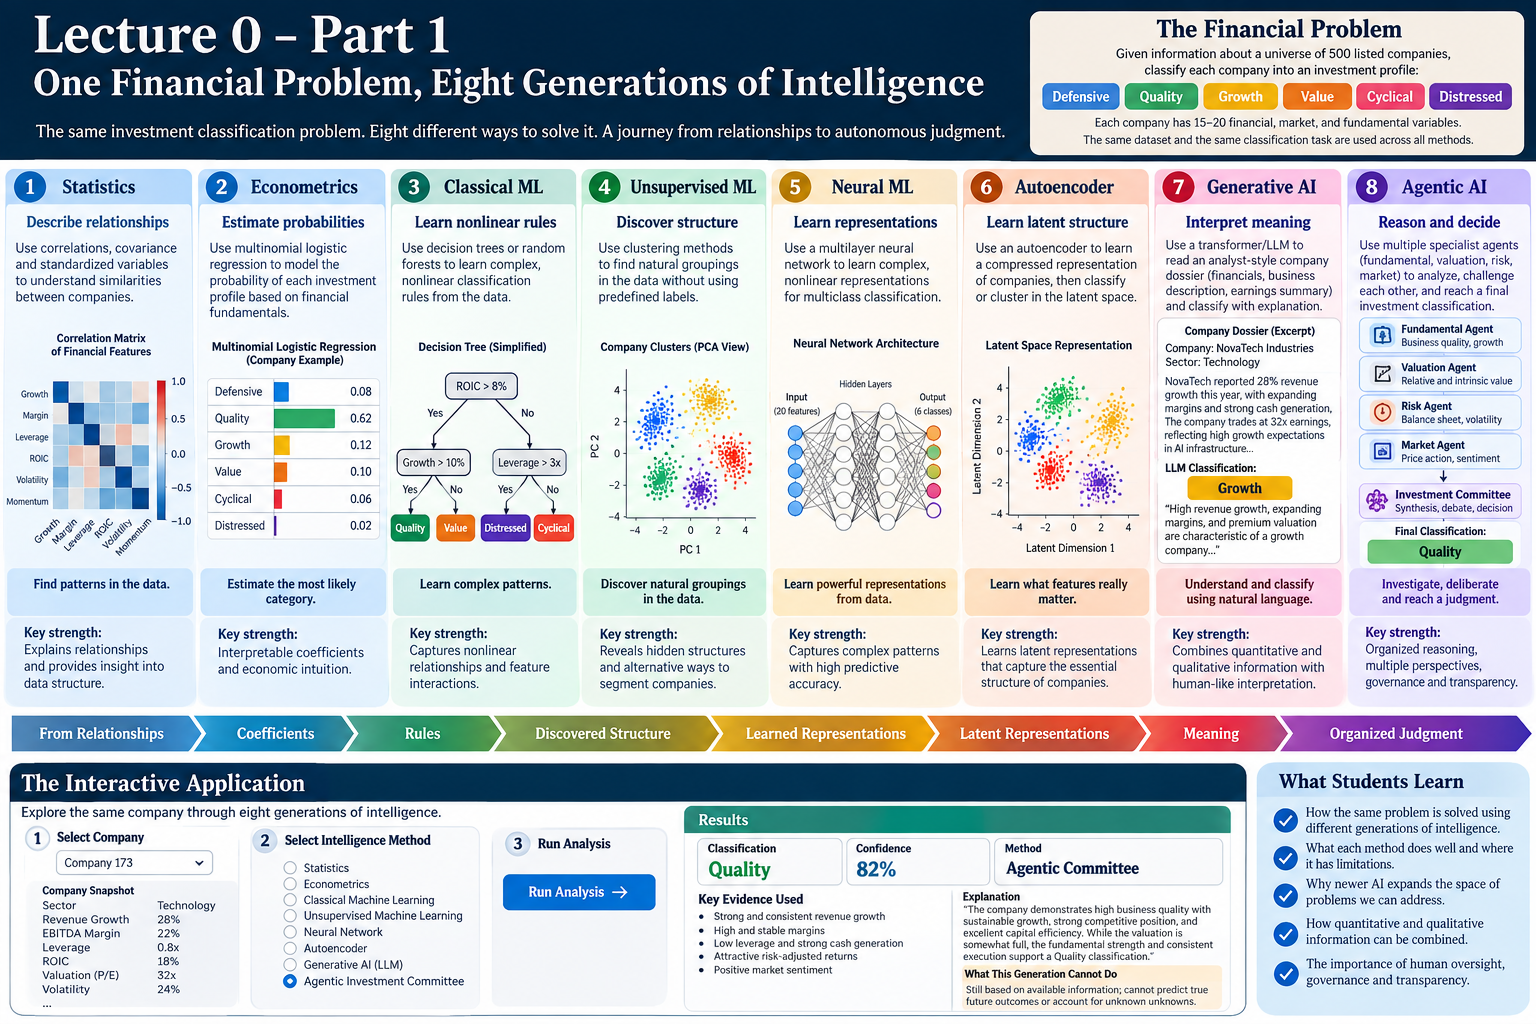

## Cell 1 — One universe, one mandate, one controlled experiment

The experiment begins by constructing a synthetic universe of 500 companies. Every subsequent generation of intelligence operates on this same economic environment. This is essential. If we changed the dataset and task every time we changed the method, students could not distinguish genuine technological differences from differences in the problem itself.

Each company receives financial and market attributes practitioners immediately recognize: growth, margins, return on invested capital, leverage, valuation, volatility, momentum, recurring revenue and free-cash-flow conversion. The data are generated around six hidden investment archetypes—Defensive, Quality, Growth, Value, Cyclical and Distressed—so the categories have coherent but overlapping economic characteristics. Real companies are obviously more complicated; the purpose is controlled pedagogy rather than security selection.

This cell is the equivalent of building the laboratory. It defines the observable world, classification mandate and reference labels against which supervised methods can be evaluated. We deliberately preserve overlap and noise. A perfectly separable dataset would teach the wrong lesson because real financial classification contains ambiguity.

The cell also creates analyst-style company dossiers. These transform selected numerical observations into natural-language descriptions. The dossiers become important later when we move from tabular models to generative intelligence. At that point the underlying company remains the same, but its representation changes.

As you inspect the data, focus on the distinction between **the problem** and **the method**. The problem is stable: classify companies into useful investment profiles. What changes over the notebook is the machinery available to solve it. That controlled progression lets us see intelligence expand from measurable relationships toward semantic interpretation and organized judgment.

In [1]:
# @title
# Cell 1 — Create one synthetic universe of 500 companies
import sys, subprocess, importlib.util, json, re, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import euclidean_distances

np.random.seed(42); random.seed(42)
profiles=["Defensive","Quality","Growth","Value","Cyclical","Distressed"]
params={
"Defensive":[8,20,13,1.2,16,15,72,78],
"Quality":[14,29,22,.8,24,18,78,88],
"Growth":[31,18,15,1.5,38,29,68,62],
"Value":[9,17,12,1.8,10,24,55,72],
"Cyclical":[18,15,11,2.0,14,33,42,60],
"Distressed":[-4,3,1,4.2,7,48,28,22]}
rows=[]
for i in range(500):
    p=profiles[i%6]
    g,m,roic,lev,pe,vol,rec,fcf=params[p]
    vals=[np.random.normal(g,5),np.random.normal(m,4),np.random.normal(roic,4),
          max(0,np.random.normal(lev,.55)),max(2,np.random.normal(pe,4)),
          max(5,np.random.normal(vol,5)),np.clip(np.random.normal(rec,9),0,100),
          np.clip(np.random.normal(fcf,10),0,110),np.random.normal(g*.35,7)]
    rows.append([f"Company-{i+1:03d}",p]+vals)
cols=["company","profile","growth_pct","ebitda_margin_pct","roic_pct","leverage_x",
      "pe_x","volatility_pct","recurring_revenue_pct","fcf_conversion_pct","momentum_pct"]
df=pd.DataFrame(rows,columns=cols).sample(frac=1,random_state=42).reset_index(drop=True)
features=cols[2:]
df["dossier"]=df.apply(lambda r:
 f"{r.company} reports revenue growth of {r.growth_pct:.1f}%, EBITDA margin of {r.ebitda_margin_pct:.1f}%, "
 f"ROIC of {r.roic_pct:.1f}%, leverage of {r.leverage_x:.1f}x and a P/E of {r.pe_x:.1f}x. "
 f"Volatility is {r.volatility_pct:.1f}%, recurring revenue is {r.recurring_revenue_pct:.0f}%, "
 f"free-cash-flow conversion is {r.fcf_conversion_pct:.0f}% and momentum is {r.momentum_pct:.1f}%.",axis=1)
display(Markdown("### The fixed mandate\nClassify each company as **Defensive, Quality, Growth, Value, Cyclical, or Distressed**."))
display(df.head(10))


### The fixed mandate
Classify each company as **Defensive, Quality, Growth, Value, Cyclical, or Distressed**.

,company,profile,growth_pct,ebitda_margin_pct,roic_pct,leverage_x,pe_x,volatility_pct,recurring_revenue_pct,fcf_conversion_pct,momentum_pct,dossier
0,Company-362,Quality,4.710493,31.412990,23.192634,1.151263,28.232473,19.838099,79.332805,79.189317,-0.085545,"Company-362 reports revenue growth of 4.7%, EB..."
1,Company-074,Quality,13.879375,29.792339,21.422558,0.484486,21.812564,17.836234,73.109177,80.871542,5.645012,"Company-074 reports revenue growth of 13.9%, E..."
2,Company-375,Growth,28.370602,18.711000,16.601926,1.572086,37.690226,23.023531,81.058348,80.071966,-0.928611,"Company-375 reports revenue growth of 28.4%, E..."
3,Company-156,Distressed,-3.076598,-2.388505,-2.886456,4.860228,4.372423,42.765445,32.829875,33.857042,3.632673,"Company-156 reports revenue growth of -3.1%, E..."
4,Company-105,Growth,25.893836,20.833426,15.975203,1.189757,32.878782,33.362287,73.851811,61.008241,23.776459,"Company-105 reports revenue growth of 25.9%, E..."
5,Company-395,Cyclical,21.435329,20.866163,6.553679,1.980296,11.874182,25.160703,45.120390,85.115566,-6.580544,"Company-395 reports revenue growth of 21.4%, E..."
6,Company-378,Distressed,-4.378328,10.890169,-4.543952,4.478074,12.956452,59.357249,24.360423,26.914295,2.588323,"Company-378 reports revenue growth of -4.4%, E..."
7,Company-125,Cyclical,30.017078,14.769525,11.804396,2.577860,18.422104,38.935152,47.748572,48.569951,17.734021,"Company-125 reports revenue growth of 30.0%, E..."
8,Company-069,Growth,32.399843,13.498044,24.783008,1.571072,38.437579,32.628833,72.329083,64.238840,5.316679,"Company-069 reports revenue growth of 32.4%, E..."
9,Company-451,Defensive,4.309715,20.725005,14.841086,1.307163,11.921219,16.031809,85.159763,82.486358,9.533910,"Company-451 reports revenue growth of 4.3%, EB..."


## Cell 2 — Statistics: intelligence as relationships and similarity

Our first generation is intentionally modest. Statistics does not need to produce sophisticated autonomous judgment to be useful. It gives us a disciplined language for describing the financial world. We standardize company characteristics, examine correlations, and classify each company by proximity to the average profile of each investment archetype.

This method asks a fundamental question: **Which known profile does this company most resemble?** The answer comes from measurable distance in standardized financial space. No nonlinear learning occurs. No language is interpreted. No hidden representation is discovered. Yet the procedure is systematic, reproducible and informative.

The correlation matrix is equally important. It shows that intelligence can begin with understanding relationships rather than making predictions. Growth may be associated with valuation. Quality may appear through margins and ROIC. Distress may combine leverage, weak cash generation and volatility. These relationships help an analyst understand the structure of the data before constructing more ambitious models.

This generation also establishes a baseline for interpretability. We can explain why a company is close to a particular centroid: its standardized characteristics resemble that group's average characteristics. Later models may be more flexible, but their internal logic can become harder to inspect.

The lesson is not that statistics is primitive and therefore disposable. Statistical intelligence remains embedded inside almost every later generation. Standardization, distributions, covariance and diagnostics continue to matter. The ladder is cumulative.

When the output appears, ask what this method can and cannot know. It can describe measurable similarity. It cannot discover semantic meaning from a filing, reason about an unusual strategic event, or coordinate multiple perspectives. Its limits define the frontier that motivates the next generation.

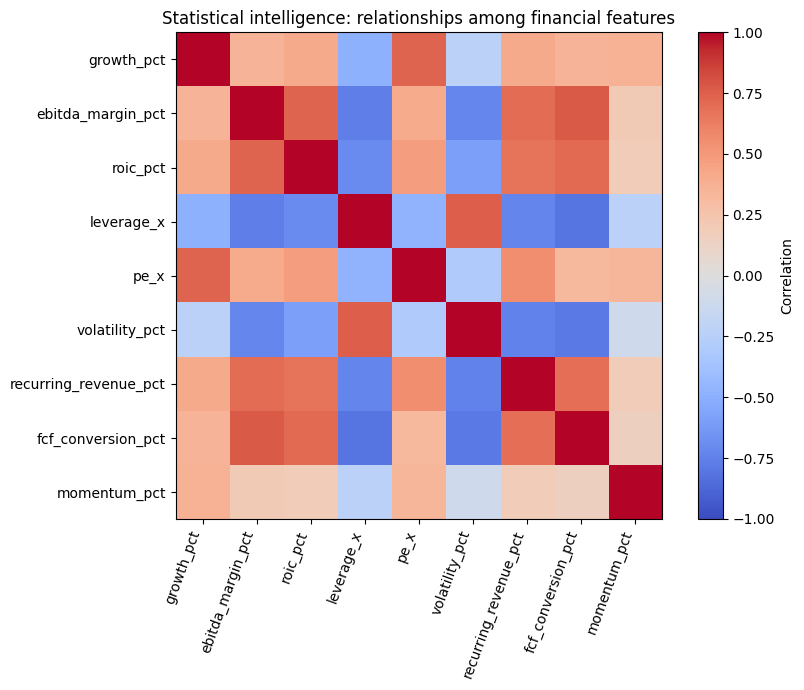

Nearest-archetype accuracy: 0.97


,company,profile,statistics_prediction
0,Company-362,Quality,Quality
1,Company-074,Quality,Quality
2,Company-375,Growth,Growth
3,Company-156,Distressed,Distressed
4,Company-105,Growth,Growth
5,Company-395,Cyclical,Value
6,Company-378,Distressed,Distressed
7,Company-125,Cyclical,Cyclical
8,Company-069,Growth,Growth
9,Company-451,Defensive,Defensive


In [2]:
# @title
# Cell 2 — Statistics: correlations and nearest archetype
scaler=StandardScaler()
Xz=scaler.fit_transform(df[features])
corr=df[features].corr()
plt.figure(figsize=(9,7)); plt.imshow(corr,cmap="coolwarm",vmin=-1,vmax=1)
plt.xticks(range(len(features)),features,rotation=70,ha="right")
plt.yticks(range(len(features)),features); plt.colorbar(label="Correlation")
plt.title("Statistical intelligence: relationships among financial features")
plt.tight_layout(); plt.show()
Z=pd.DataFrame(Xz,columns=features,index=df.index)
centroids=Z.assign(profile=df.profile).groupby("profile").mean().loc[profiles]
dist=euclidean_distances(Z,centroids)
df["statistics_prediction"]=[profiles[i] for i in dist.argmin(axis=1)]
print("Nearest-archetype accuracy:",round(accuracy_score(df.profile,df.statistics_prediction),3))
display(df[["company","profile","statistics_prediction"]].head(12))


## Cell 3 — Econometrics: from resemblance to estimated probabilities

Econometrics adds a model of conditional classification. We use multinomial logistic regression to estimate the probability that a company belongs to each of the six investment profiles given its observed financial characteristics. This is an important conceptual advance over simple similarity.

The model does not merely say that a company is near the average Growth firm. It estimates a mapping from explanatory variables to category probabilities. The result is a probability distribution across the six profiles. Ambiguity becomes visible: a company might be mostly Quality but retain meaningful probabilities of Defensive or Value rather than being treated as an unquestionable label.

The coefficients connect prediction to economic interpretation. Positive growth may increase the relative likelihood of Growth; leverage and volatility may push observations toward Distressed; margins and ROIC may support Quality. Because this is a synthetic teaching environment, coefficients should not be interpreted causally. Their purpose is to show how a structured parametric model turns measurable evidence into estimated probabilities.

We evaluate the model on held-out observations. That distinction between training and testing is essential. A model's ability to describe data it has already seen is not the same as its ability to generalize.

This generation expands the problem space from descriptive relationships toward probabilistic prediction. But it still requires structured numerical features and a predefined outcome. It cannot decide that the institution's categories themselves are wrong. It cannot read narrative evidence. It cannot discover an entirely new market structure.

That limitation naturally leads to the next generations. Classical machine learning relaxes some functional assumptions, while unsupervised learning eventually removes the requirement that categories be supplied in advance.

In [3]:
# @title
# Cell 3 — Econometrics: multinomial logistic probabilities
X=df[features]; y=df.profile
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.25,random_state=42,stratify=y)
sc_e=StandardScaler().fit(Xtr)
logit=LogisticRegression(max_iter=2000)
logit.fit(sc_e.transform(Xtr),ytr)
pred=logit.predict(sc_e.transform(Xte))
print("Held-out accuracy:",round(accuracy_score(yte,pred),3))
df["econometrics_prediction"]=logit.predict(sc_e.transform(X))
probs=logit.predict_proba(sc_e.transform(X))
display(pd.DataFrame({"profile":logit.classes_,"probability":probs[0]}).sort_values("probability",ascending=False))


Held-out accuracy: 0.944


,profile,probability
4,Quality,9.817127e-01
1,Defensive,1.757650e-02
3,Growth,5.868571e-04
5,Value,1.203839e-04
0,Cyclical,3.468591e-06
2,Distressed,5.282441e-08


## Cell 4 — Classical machine learning: learn nonlinear rules

A random forest changes the geometry of the classification problem. Instead of imposing a single parametric relationship between features and outcomes, the model learns nonlinear partitions and interactions. A company may be classified as Quality because ROIC is high, leverage is low and margins exceed a threshold, while another path can reach the same category through a different combination of evidence.

We use a random forest because it demonstrates classical machine learning without requiring neural architecture. Multiple trees are trained on variations of the data and their predictions are aggregated. The model can capture interactions that a simple multinomial regression may miss.

This is also a good moment to separate predictive power from explanatory simplicity. A forest can improve classification while making the overall decision rule less transparent than a compact regression. Feature importance provides one summary, but it does not recreate the full logic of hundreds of tree paths.

The key intellectual transition is from **estimating coefficients** to **learning rules from examples**. The practitioner specifies the features and target, but the model has more freedom in how it maps one to the other.

We again evaluate on held-out data and generate classifications for the full universe. The output can be compared directly with econometrics because the underlying task has not changed.

Notice, however, that this remains supervised intelligence. The six categories are supplied by us. The model becomes excellent at reproducing a taxonomy defined by the institution, but it does not ask whether another structure might exist in the data. The next cell removes the labels and lets the machine discover groupings for itself.

Held-out accuracy: 0.952


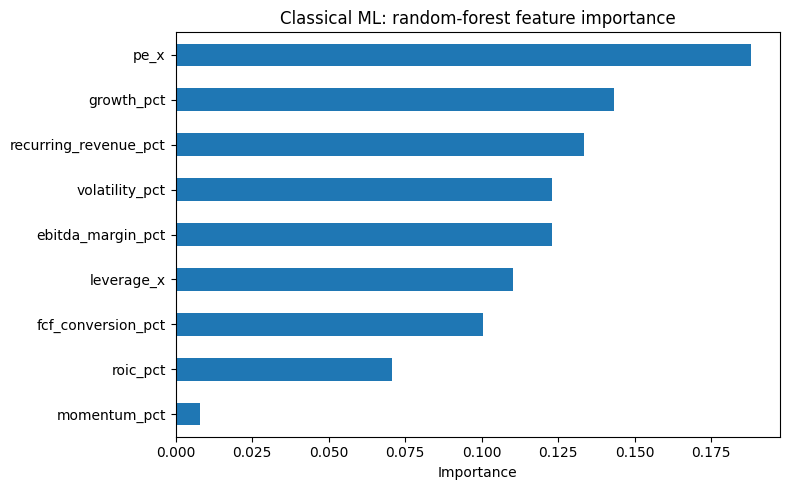

In [4]:
# @title
# Cell 4 — Classical ML: random forest learns nonlinear rules
Xtr,Xte,ytr,yte=train_test_split(df[features],df.profile,test_size=.25,random_state=42,stratify=df.profile)
rf=RandomForestClassifier(n_estimators=300,max_depth=8,min_samples_leaf=3,random_state=42)
rf.fit(Xtr,ytr)
pred=rf.predict(Xte)
print("Held-out accuracy:",round(accuracy_score(yte,pred),3))
df["ml_prediction"]=rf.predict(df[features])
imp=pd.Series(rf.feature_importances_,index=features).sort_values()
plt.figure(figsize=(8,5)); imp.plot(kind="barh")
plt.title("Classical ML: random-forest feature importance"); plt.xlabel("Importance"); plt.tight_layout(); plt.show()


## Cell 5 — Unsupervised learning: discover structure rather than reproduce labels

Clustering changes the question. Until now, every classifier has been told what the six investment profiles are. In this cell we temporarily hide those labels and ask an unsupervised algorithm to organize the company universe based only on financial similarity.

K-means creates groups in standardized feature space. Principal-component analysis then gives us a two-dimensional representation for visualization. The resulting clusters are not automatically Defensive, Quality, Growth, Value, Cyclical or Distressed. Cluster numbers have no inherent economic meaning. We inspect their average characteristics and compare them with the reference archetypes.

This is a different kind of intelligence. Instead of predicting an answer supplied by humans, the method reveals patterns that may not have been specified in advance. In real finance, analogous techniques can discover customer segments, trading regimes, peer groups, anomalies or latent market structures.

The method also illustrates why human interpretation remains important. A cluster is a mathematical grouping, not a business conclusion. Its meaning depends on feature choice, scaling, the number of clusters and economic context. A responsible practitioner does not simply rename Cluster 2 “Quality” because a visualization looks convenient.

The expansion of the problem space is therefore clear. Supervised methods answer: “Given our taxonomy, where does this company belong?” Unsupervised learning can ask: “What taxonomy does the data suggest?”

This capability matters when AI systems operate in environments where relevant categories are not known beforehand. The machine discovers structure, but humans still supply meaning.

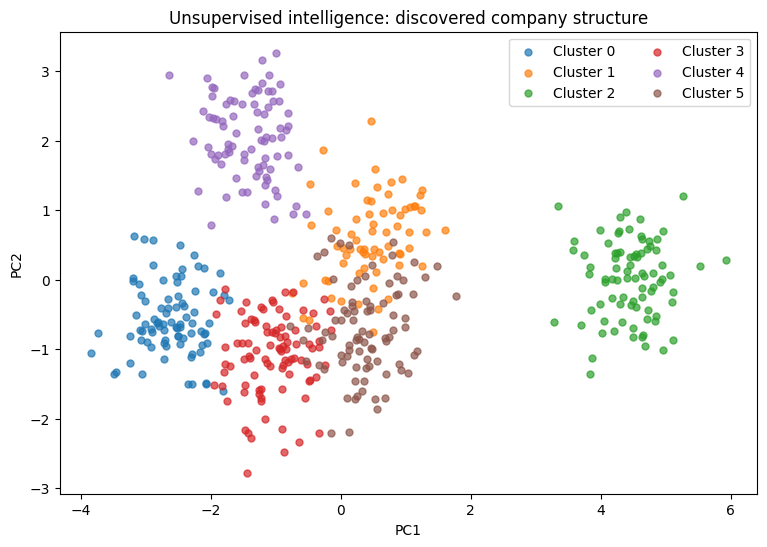

profile,Cyclical,Defensive,Distressed,Growth,Quality,Value
cluster,,,,,,
0,0,0,0,0,84,0
1,50,0,0,0,0,20
2,0,0,83,0,0,0
3,0,82,0,0,0,11
4,0,0,0,83,0,0
5,33,2,0,0,0,52


In [5]:
# @title
# Cell 5 — Unsupervised ML: discover structure without labels
Xu=StandardScaler().fit_transform(df[features])
km=KMeans(n_clusters=6,n_init=30,random_state=42)
df["cluster"]=km.fit_predict(Xu)
P=PCA(n_components=2,random_state=42).fit_transform(Xu)
plt.figure(figsize=(9,6))
for c in sorted(df.cluster.unique()):
    m=df.cluster==c; plt.scatter(P[m,0],P[m,1],s=25,alpha=.7,label=f"Cluster {c}")
plt.title("Unsupervised intelligence: discovered company structure")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(ncol=2); plt.show()
cluster_profile=pd.crosstab(df.cluster,df.profile)
display(cluster_profile)
cluster_map=cluster_profile.idxmax(axis=1).to_dict()
df["unsupervised_interpretation"]=df.cluster.map(cluster_map)


## Cell 6 — Neural machine learning: learn nonlinear representations

The neural network introduces representation learning into the supervised classification problem. We use a multilayer perceptron with hidden layers between the financial inputs and six-category output. During training, the network adjusts internal weights so combinations of features become useful intermediate representations for classification.

This is conceptually different from manually defining a financial score. Hidden units are not explicitly labeled “quality,” “growth persistence” or “balance-sheet strength.” They are learned transformations that help reduce classification error. The representation is instrumental: it becomes useful because it supports the task.

We retain the same train/test discipline used earlier. The network receives standardized financial variables, learns from labeled examples and produces classifications across the six profiles. Its performance can be compared with regression and random forests, but accuracy alone is not the pedagogical objective.

The deeper transition is that we increasingly allow the machine to determine **how information should be represented internally**. This principle becomes central to modern AI. Deep learning succeeded in many domains partly because useful features no longer had to be completely hand-engineered.

Yet the neural classifier remains bounded by the supervised task. It learns representations useful for reproducing labels we provided. It does not necessarily learn a general description of the company universe.

That distinction motivates the autoencoder in the next cell. There, representation itself becomes the primary object. Instead of asking the network only to classify a company, we ask it to compress and reconstruct financial information through a bottleneck. We can then examine the latent space that emerges.

Held-out accuracy: 0.872
              precision    recall  f1-score   support

   Defensive      1.000     0.571     0.727        21
     Quality      0.889     0.762     0.821        21
      Growth      0.952     1.000     0.976        20
       Value      1.000     1.000     1.000        21
    Cyclical      0.955     1.000     0.977        21
  Distressed      0.613     0.905     0.731        21

    accuracy                          0.872       125
   macro avg      0.901     0.873     0.872       125
weighted avg      0.901     0.872     0.871       125



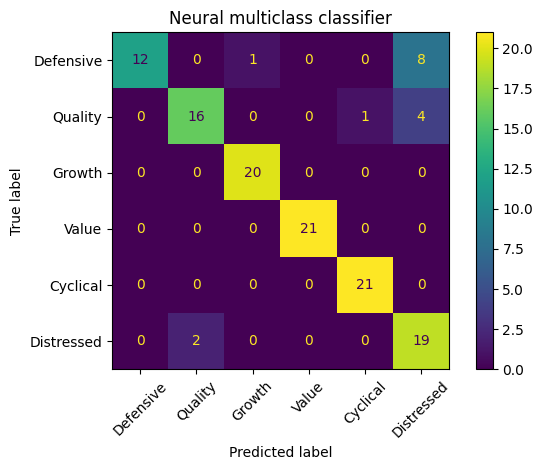

In [6]:
# @title
import sklearn.preprocessing
from sklearn.preprocessing import LabelEncoder

# Cell 6 — Neural ML: nonlinear multiclass classifier
Xn=StandardScaler().fit_transform(df[features])

# Encode string labels to numerical labels
le = LabelEncoder()
y_encoded = le.fit_transform(df.profile)

Xtr,Xte,ytr_encoded,yte_encoded=train_test_split(Xn,y_encoded,test_size=.25,random_state=42,stratify=y_encoded)

nn=MLPClassifier(hidden_layer_sizes=(32,16),activation="relu",max_iter=1800,
                 early_stopping=True,random_state=42)
nn.fit(Xtr,ytr_encoded)
yp_encoded=nn.predict(Xte)

print("Held-out accuracy:",round(accuracy_score(yte_encoded,yp_encoded),3))
print(classification_report(le.inverse_transform(yte_encoded), le.inverse_transform(yp_encoded), digits=3, target_names=profiles))

df["neural_prediction"]=le.inverse_transform(nn.predict(Xn))
ConfusionMatrixDisplay.from_predictions(le.inverse_transform(yte_encoded), le.inverse_transform(yp_encoded), display_labels=profiles, xticks_rotation=45)
plt.title("Neural multiclass classifier"); plt.tight_layout(); plt.show()

## Cell 7 — Autoencoder: representation itself becomes the object

An autoencoder is trained to reproduce its own input after forcing information through a lower-dimensional bottleneck. The network therefore has to learn a compressed representation that preserves enough structure to reconstruct the original company characteristics.

For this teaching notebook we use a compact neural reconstruction network with a two-dimensional bottleneck. The input is the standardized financial vector; the target is that same vector. After training, we extract the hidden two-dimensional representation for every company and visualize the latent space colored by the original investment profiles.

This is a subtle but important step in the progression. Regression learns coefficients useful for a specified outcome. A random forest learns nonlinear rules useful for classification. A supervised neural network learns hidden representations useful for labels. The autoencoder learns a representation from the structure of the inputs themselves.

If companies with similar economic characteristics occupy nearby regions of latent space, the network has discovered a compressed organization of the universe. It may not align perfectly with our six human-defined archetypes—and that is informative.

Representation learning becomes increasingly important as data grow more complex. Images, language, audio and high-dimensional financial information cannot always be reduced to a few hand-selected variables without losing useful structure.

Still, the autoencoder does not understand the *meaning* of an analyst's sentence. It works with numerical vectors. The next transition is qualitative. We convert the company into an analyst-style dossier and ask a transformer-based language model to interpret financial information expressed in natural language. The problem space expands from numerical representation toward semantic representation.

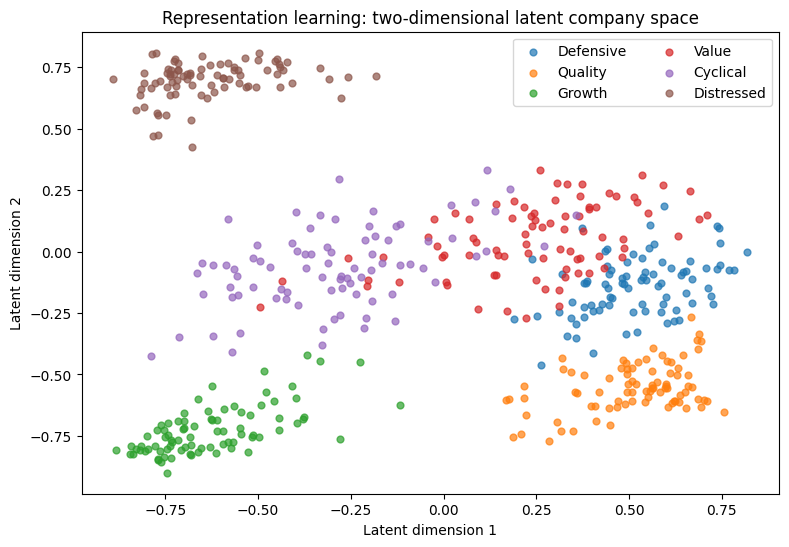

In [7]:
# @title
# Cell 7 — Autoencoder-style latent representation
Xa=StandardScaler().fit_transform(df[features])
ae=MLPRegressor(hidden_layer_sizes=(12,2,12),activation="tanh",solver="adam",
                max_iter=2500,random_state=42,early_stopping=True)
ae.fit(Xa,Xa)
W1,b1=ae.coefs_[0],ae.intercepts_[0]; W2,b2=ae.coefs_[1],ae.intercepts_[1]
h1=np.tanh(Xa@W1+b1); latent=np.tanh(h1@W2+b2)
df["latent_1"]=latent[:,0]; df["latent_2"]=latent[:,1]
plt.figure(figsize=(9,6))
for p in profiles:
    m=df.profile==p
    plt.scatter(df.loc[m,"latent_1"],df.loc[m,"latent_2"],s=24,alpha=.7,label=p)
plt.title("Representation learning: two-dimensional latent company space")
plt.xlabel("Latent dimension 1"); plt.ylabel("Latent dimension 2"); plt.legend(ncol=2); plt.show()
df["latent_cluster"]=KMeans(n_clusters=6,n_init=30,random_state=42).fit_predict(latent)


## Cell 8 — Generative AI: from numerical representation to meaning

Claude Haiku 4.5 enters only at this point because we now give the machine a problem for which language understanding matters. Each selected company is represented as an analyst-style dossier containing financial facts and qualitative context. Claude must classify the company into one of the six investment profiles and explain its reasoning using only the supplied synthetic evidence.

The model is `claude-haiku-4-5-20251001`. The API key is read from Colab Secrets under `ANTHROPIC_API_KEY`; it is never printed. We use a non-zero temperature of 0.2 and explicit JSON validation. If the live API call fails, the notebook raises an error. It does not silently substitute a deterministic rule and pretend the result came from Claude.

This is an important governance choice because the pedagogical distinction between a real model response and a fallback heuristic must remain visible.

The LLM's comparative advantage is not that it should necessarily beat a random forest on clean tabular data. Instead, it can interpret a flexible semantic representation. A dossier can contain statements about business quality, operating trends, strategic events or management commentary that do not fit neatly into a fixed feature schema.

The analytical object has therefore changed again. Earlier generations learned relationships, probabilities, rules and numerical representations. Generative AI can work with **meaning expressed through language**.

Its weaknesses also change. Language-model outputs can vary, hallucinate or overstate confidence. Numerical calculations should not be delegated blindly to prose generation. The appropriate lesson is complementarity: generative intelligence expands what the system can consume and discuss, but it does not erase the value of quantitative methods.

In [8]:
# @title
import sklearn.preprocessing
from sklearn.preprocessing import LabelEncoder
import sys, subprocess, importlib.util, json, re, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import euclidean_distances

# Cell 8 — Generative AI: Claude interprets company dossiers
if importlib.util.find_spec("anthropic") is None:
    subprocess.check_call([sys.executable,"-m","pip","install","-q","anthropic>=0.69.0"])
from google.colab import userdata
from anthropic import Anthropic
try:
    api_key=userdata.get("ANTHROPIC_API_KEY")
except Exception:
    raise RuntimeError("Add ANTHROPIC_API_KEY in Colab Secrets and enable notebook access.") from None
if not api_key: raise RuntimeError("ANTHROPIC_API_KEY is empty.")
MODEL="claude-haiku-4-5-20251001"
client=Anthropic(api_key=api_key,timeout=60.0,max_retries=1)
del api_key
API_CALLS=0; MAX_API_CALLS=30
def ask_claude(prompt,max_tokens=900):
    global API_CALLS
    if API_CALLS>=MAX_API_CALLS: raise RuntimeError("Claude API call budget exhausted.")
    API_CALLS+=1
    try:
        r=client.messages.create(model=MODEL,max_tokens=max_tokens,
            messages=[{"role":"user","content":prompt}])
        return "".join(getattr(b,"text","") for b in r.content if getattr(b,"type","")=="text")
    except Exception as e:
        raise RuntimeError(f"Claude API call failed explicitly: {type(e).__name__}: {e}") from e
def parse_json(txt):
    cleaned=re.sub(r"^```(?:json)?|```$","",txt.strip(),flags=re.M).strip()
    try: return json.loads(cleaned)
    except Exception as e: raise RuntimeError(f"Invalid JSON from Claude: {txt[:400]}") from e
llm_results={}
demo_names=df.sample(6,random_state=19).company.tolist()
for name in demo_names:
    r=df.loc[df.company==name].iloc[0]
    prompt=f"""Synthetic educational investment-classification exercise.
Classify the company as exactly one of: {", ".join(profiles)}.
Use ONLY the dossier. Return JSON only with keys classification, confidence, evidence, explanation, limitation.
DOSSIER: {r.dossier}"""
    llm_results[name]=parse_json(ask_claude(prompt))
display(pd.DataFrame(llm_results).T)

,classification,confidence,evidence,explanation,limitation
Company-407,Growth,0.72,[Revenue growth of 18.7% significantly exceeds...,Company-407 exhibits primary Growth characteri...,Classification confidence is moderately constr...
Company-010,Value,0.78,"[P/E of 8.0x is notably low, suggesting underv...",The combination of a low P/E multiple (8.0x) w...,ROIC of 9.9% is modest and could suggest capit...
Company-108,Distressed,0.78,[Negative revenue growth of -0.5% indicates de...,Company-108 exhibits multiple distress indicat...,Classification relies on static metrics withou...
Company-388,Value,0.72,"[P/E of 12.7x is below typical market average,...",Company-388 exhibits the primary characteristi...,Classification confidence is moderate (0.72) b...
Company-293,Growth,0.72,[Revenue growth of 15.8% exceeds typical marke...,Company-293 exhibits primary Growth characteri...,Classification confidence is tempered by moder...
Company-323,Growth,0.72,[Revenue growth of 16.6% significantly above t...,Company-323 exhibits primary Growth characteri...,Classification confidence reduced by: (1) vola...


## Cell 9 — Agentic judgment: organize multiple perspectives around the same company

The final analytical generation moves beyond a single LLM response. We create four specialist perspectives: Fundamental Analyst, Valuation Analyst, Risk Analyst and Market Analyst. Each receives the same synthetic company dossier but examines it through a different professional lens. A fifth Claude call acts as the Investment Committee and synthesizes those perspectives into a final classification, preserving disagreements and explaining the decision.

This is the beginning of agentic architecture. The innovation is not a mysterious new base model. All specialists can use the same Claude Haiku model. What changes is the **organization of cognition**. Roles, information boundaries, independent perspectives and synthesis become part of the intelligence system.

This matters because many professional decisions cannot be reduced to one scalar prediction. A company may exhibit excellent fundamentals but expensive valuation. A risk specialist may identify fragility that a growth-oriented analyst discounts. Market behavior may contradict the fundamental story. An intelligent committee should not hide those tensions.

The exercise remains bounded. The agents use only synthetic evidence. They do not trade, contact companies or claim execution authority. Their output is judgment, not action.

This generation therefore expands the problem space from semantic interpretation toward **structured deliberation**. It demonstrates how models can be composed into an institution-like process.

Students should pay attention to a subtle point: more agents do not automatically mean more intelligence. Poorly differentiated roles can create redundant verbosity. Groupthink can emerge if agents see each other's answers too early. Governance and architecture determine whether the constellation adds value.

The final cell brings all eight generations into one interactive laboratory so these differences can be inspected side by side.

In [10]:
# @title
# Cell 9 — Agentic AI: four specialists plus investment committee
agentic_results={}; agent_demo=demo_names[:2]
roles={"Fundamental Analyst":"Focus on growth, margins, ROIC, recurring revenue and cash generation.",
"Valuation Analyst":"Focus on valuation relative to operating characteristics.",
"Risk Analyst":"Focus on leverage, volatility, fragility and downside evidence.",
"Market Analyst":"Focus on momentum and market behavior."}
for name in agent_demo:
    r=df.loc[df.company==name].iloc[0]; views={}
    for role,instruction in roles.items():
        prompt=f"""You are the {role} in a synthetic educational investment committee.
{instruction}
Use ONLY this dossier: {r.dossier}
Return JSON only with keys preferred_profile, evidence, concern.
preferred_profile must be one of: {", ".join(profiles)}."""
        views[role]=parse_json(ask_claude(prompt,max_tokens=650))
    committee_prompt=f"""You are the Investment Committee chair in a synthetic teaching exercise.
Company dossier: {r.dossier}
Specialist views: {json.dumps(views)}
Synthesize the evidence. Preserve material disagreement.
Return JSON only with keys final_classification, confidence, consensus, dissent, rationale, limitation.
final_classification must be one of: {", ".join(profiles)}.
Do not claim trading or execution authority."""
    committee=parse_json(ask_claude(committee_prompt,max_tokens=900))
    agentic_results[name]={"specialists":views,"committee":committee}
for name,res in agentic_results.items():
    display(Markdown(f"### {name}")); display(pd.DataFrame(res["specialists"]).T); display(res["committee"])

### Company-407

,preferred_profile,evidence,concern
Fundamental Analyst,Growth,[Revenue growth of 18.7% demonstrates above-ma...,[EBITDA margin of 16.5% is moderate; margin ex...
Valuation Analyst,Quality,[EBITDA margin of 16.5% demonstrates solid ope...,[High volatility of 44.1% conflicts with Quali...
Risk Analyst,Value,[P/E of 14.6x is below historical market avera...,"[Volatility at 44.1% is elevated, indicating s..."
Market Analyst,Growth,[Revenue growth of 18.7% demonstrates strong t...,"[Volatility of 44.1% is elevated, suggesting e..."


{'final_classification': 'Growth',
 'confidence': 0.62,
 'consensus': ['Revenue growth of 18.7% is genuinely above-market and the primary positive signal across all views',
  'P/E of 14.6x is reasonable and not premium-priced relative to growth rate; no valuation bubble',
  'Leverage of 0.9x is conservative and provides financial stability',
  'ROIC of 11.0% exceeds cost of capital in base scenarios, supporting productive deployment'],
 'dissent': ['Volatility of 44.1% creates fundamental tension: analysts agree it is elevated but disagree on its meaning. Growth and Market analysts treat it as acceptable execution risk; Risk and Valuation analysts view it as conflicting with stated profile sustainability.',
  'FCF conversion of 53% is universally flagged but interpreted differently: Fundamental/Market analysts see it as manageable for growth stage; Risk/Valuation analysts interpret it as a quality-of-earnings red flag suggesting working capital strain or unsustainable capex intensity.'

### Company-010

,preferred_profile,evidence,concern
Fundamental Analyst,Value,[P/E of 8.0x is attractive and suggests underv...,[Revenue growth of 10.8% is modest and insuffi...
Valuation Analyst,Value,[P/E of 8.0x is materially below market averag...,[Revenue growth of 10.8% is modest relative to...
Risk Analyst,Value,[P/E of 8.0x is significantly below market ave...,"[Volatility of 28.6% is elevated, indicating m..."
Market Analyst,Value,[P/E of 8.0x is significantly below market ave...,"[Revenue growth of 10.8% is modest, not indica..."


{'final_classification': 'Value',
 'confidence': 0.72,
 'consensus': ['P/E of 8.0x represents material undervaluation relative to market averages',
  'EBITDA margin of 22.9% demonstrates solid operational efficiency',
  'Leverage of 1.4x is moderate and manageable',
  'All four specialists converge on Value classification as preferred profile',
  'FCF conversion of 67% shows reasonable cash generation discipline'],
 'dissent': ["Fundamental Analyst and Risk Analyst emphasize ROIC of 9.9% as below cost of capital and a capital allocation concern; Valuation Analyst characterizes ROIC as 'reasonable' and above WACC thresholds—material disagreement on value creation cushion",
  'Risk Analyst weights fragility risk (high volatility + weak momentum + marginal ROIC) as a material downside scenario; other analysts acknowledge volatility but do not explicitly flag deterioration risk',
  'Market Analyst suggests low multiple may reflect market skepticism about business quality; Fundamental Analy

## Cell 10 — Comparative laboratory: one company, eight generations

The final cell turns the notebook into an interactive Gradio application. The student selects a company and then chooses one of eight generations of intelligence: Statistics, Econometrics, Classical Machine Learning, Unsupervised Machine Learning, Neural Network, Autoencoder, Generative AI or Agentic Investment Committee.

The application deliberately avoids presenting methods as a leaderboard. Instead, it displays what each generation contributes: its classification or structural output, the evidence it uses, an explanation of its mechanism, and—most importantly—**what that generation cannot do**.

That last field is central to the lecture. If a random forest happens to classify synthetic companies more accurately than Claude, nothing has gone wrong. The notebook is not designed to prove that newer technology always wins. A mature financial institution should use the simplest and most reliable method appropriate to the problem.

The historical progression matters because the feasible problem set expands. Statistics gives relationships and similarity. Econometrics gives conditional probabilities. Machine learning learns nonlinear rules. Unsupervised methods discover structure. Neural systems learn representations. Autoencoders expose latent structure. Generative models interpret language and meaning. Agentic architectures organize multiple perspectives into judgment.

The app therefore becomes a compact map of the lecture. Students can hold the company constant while changing the intelligence mechanism. This makes methodological differences tangible.

It also prepares the conceptual transition to Lecture 0, Part 2. Part 1 treats generations sequentially so their distinctive capabilities can be understood. Real intelligent systems do not have to choose only one. They can combine statistics, machine learning, generative models, tools, governance and human authority into a larger architecture. Part 2 moves from the **ladder of intelligence** to the **constellation of intelligence**.

In [14]:
# @title
# ============================================================
# CELL 10 — COMPARATIVE INTELLIGENCE LABORATORY
# Lecture 0 · Part I
# One Financial Problem, Eight Generations of Intelligence
#
# Google Colab:
#   share=True  -> public Gradio-hosted URL
#   inline=False -> no localhost / embedded Colab dependency
# ============================================================

import sys
import subprocess
import importlib.util
import html


# ============================================================
# 1. LOAD GRADIO
# ============================================================

if importlib.util.find_spec("gradio") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "gradio>=4.44,<6"
    ])

import gradio as gr


# ============================================================
# 2. EIGHT GENERATIONS
# ============================================================

methods = [
    "1 · Statistics",
    "2 · Econometrics",
    "3 · Classical Machine Learning",
    "4 · Unsupervised Machine Learning",
    "5 · Neural Network",
    "6 · Representation Learning",
    "7 · Generative AI (Claude)",
    "8 · Agentic Investment Committee",
]


METHOD_META = {

    "1 · Statistics": {
        "short": "Statistics",
        "stage": "RELATIONSHIPS",
        "frontier":
            "Describe measurable relationships and financial resemblance."
    },

    "2 · Econometrics": {
        "short": "Econometrics",
        "stage": "COEFFICIENTS",
        "frontier":
            "Estimate conditional probabilities under an explicit model."
    },

    "3 · Classical Machine Learning": {
        "short": "Classical ML",
        "stage": "RULES",
        "frontier":
            "Learn nonlinear predictive rules and interactions."
    },

    "4 · Unsupervised Machine Learning": {
        "short": "Unsupervised ML",
        "stage": "DISCOVERED STRUCTURE",
        "frontier":
            "Discover structure without receiving predefined investment labels."
    },

    "5 · Neural Network": {
        "short": "Neural ML",
        "stage": "LEARNED REPRESENTATIONS",
        "frontier":
            "Learn nonlinear internal representations useful for classification."
    },

    "6 · Representation Learning": {
        "short": "Representation Learning",
        "stage": "LATENT REPRESENTATIONS",
        "frontier":
            "Learn a compressed latent geometry of the company universe."
    },

    "7 · Generative AI (Claude)": {
        "short": "Generative AI",
        "stage": "MEANING",
        "frontier":
            "Interpret heterogeneous information expressed in natural language."
    },

    "8 · Agentic Investment Committee": {
        "short": "Agentic AI",
        "stage": "ORGANIZED JUDGMENT",
        "frontier":
            "Organize specialist inquiry, disagreement, synthesis and judgment."
    },
}


# ============================================================
# 3. HTML SAFETY
# ============================================================

def _safe(x):
    return html.escape(str(x if x is not None else "—"))


# ============================================================
# 4. GET RESULT FOR SELECTED GENERATION
# ============================================================

def _result_payload(name, method):

    r = df.loc[df.company == name].iloc[0]


    # --------------------------------------------------------
    # 1 — STATISTICS
    # --------------------------------------------------------

    if method == "1 · Statistics":

        result = r.statistics_prediction

        mechanism = (
            "The company is compared with standardized investment-profile "
            "centroids. Classification follows measurable financial resemblance."
        )

        limitation = (
            "The method cannot interpret semantic context or reason about "
            "events that are not represented in the numerical feature space."
        )

        detail = "Distance-based statistical archetype"


    # --------------------------------------------------------
    # 2 — ECONOMETRICS
    # --------------------------------------------------------

    elif method == "2 · Econometrics":

        result = r.econometrics_prediction

        mechanism = (
            "A multinomial logistic model converts structured company "
            "characteristics into conditional probabilities across the "
            "six investment profiles."
        )

        limitation = (
            "The result depends on predefined variables, labels and functional "
            "specification. Predictive coefficients are not automatically causal."
        )

        detail = "Multinomial conditional estimation"


    # --------------------------------------------------------
    # 3 — CLASSICAL MACHINE LEARNING
    # --------------------------------------------------------

    elif method == "3 · Classical Machine Learning":

        result = r.ml_prediction

        mechanism = (
            "A random forest learns nonlinear predictive rules and interactions "
            "from labeled examples without imposing one global parametric equation."
        )

        limitation = (
            "The model remains dependent on labeled structured data and does "
            "not naturally interpret open-ended narrative evidence."
        )

        detail = "Nonlinear predictive rules"


    # --------------------------------------------------------
    # 4 — UNSUPERVISED MACHINE LEARNING
    # --------------------------------------------------------

    elif method == "4 · Unsupervised Machine Learning":

        result = (
            f"Cluster {int(r.cluster)} "
            f"→ {r.unsupervised_interpretation}"
        )

        mechanism = (
            "K-means discovers numerical groupings without seeing the investment "
            "profile labels. Economic meaning is attached only afterward."
        )

        limitation = (
            "Clusters have no intrinsic economic interpretation. Their structure "
            "depends on representation, scaling, distance and the number of clusters."
        )

        detail = "Structure discovered without labels"


    # --------------------------------------------------------
    # 5 — NEURAL NETWORK
    # --------------------------------------------------------

    elif method == "5 · Neural Network":

        result = r.neural_prediction

        mechanism = (
            "A multilayer neural classifier learns nonlinear internal "
            "transformations that help distinguish the six investment profiles."
        )

        limitation = (
            "The network still depends on a fixed supervised task and structured "
            "input schema. Its internal representation is less immediately interpretable."
        )

        detail = "Task-specific learned representation"


    # --------------------------------------------------------
    # 6 — REPRESENTATION LEARNING
    # --------------------------------------------------------

    elif method == "6 · Representation Learning":

        result = f"Latent cluster {int(r.latent_cluster)}"

        mechanism = (
            "The autoencoder compresses the company into a learned "
            f"two-dimensional latent position "
            f"({r.latent_1:.2f}, {r.latent_2:.2f})."
        )

        limitation = (
            "Latent geometry can reveal useful structure, but its learned "
            "dimensions do not necessarily have transparent economic meanings."
        )

        detail = "Learned latent coordinates"


    # --------------------------------------------------------
    # 7 — GENERATIVE AI
    # --------------------------------------------------------

    elif method == "7 · Generative AI (Claude)":

        if name not in llm_results:

            return r, None, (
                "The live Claude demonstration is intentionally bounded "
                "to the companies processed in Cell 8. "
                f"Choose one of: {', '.join(demo_names)}."
            )

        z = llm_results[name]

        result = z.get(
            "classification",
            "—"
        )

        mechanism = z.get(
            "explanation",
            "Claude interpreted the analyst-style dossier semantically."
        )

        limitation = z.get(
            "limitation",
            "Language-model output is stochastic and requires validation."
        )

        detail = "Semantic dossier interpretation"


    # --------------------------------------------------------
    # 8 — AGENTIC INVESTMENT COMMITTEE
    # --------------------------------------------------------

    else:

        if name not in agentic_results:

            return r, None, (
                "The agentic committee demonstration is intentionally "
                "bounded to the companies processed in Cell 9. "
                f"Choose one of: {', '.join(agent_demo)}."
            )

        z = agentic_results[name]["committee"]

        result = z.get(
            "final_classification",
            "—"
        )

        mechanism = z.get(
            "rationale",
            "Specialist perspectives were synthesized by the investment committee."
        )

        limitation = z.get(
            "limitation",
            "Organized judgment remains bounded and does not imply execution authority."
        )

        detail = "Specialist deliberation + committee synthesis"


    return r, {
        "result": result,
        "mechanism": mechanism,
        "limitation": limitation,
        "detail": detail,
    }, None


# ============================================================
# 5. BUILD RESULT PANEL
# ============================================================

def compare(name, method):

    r, payload, warning = _result_payload(name, method)

    meta = METHOD_META[method]


    # --------------------------------------------------------
    # BOUNDED DEMONSTRATION WARNING
    # --------------------------------------------------------

    if warning:

        return f"""
        <div class="result-shell">

            <div class="result-heading">

                <div>
                    <div class="eyebrow">
                        {_safe(meta['stage'])}
                    </div>

                    <div class="result-title">
                        {_safe(meta['short'])}
                    </div>
                </div>

                <div class="company-pill">
                    {_safe(name)}
                </div>

            </div>


            <div class="warning-card">

                <div class="section-label gold-label">
                    LIVE DEMONSTRATION BOUNDARY
                </div>

                <div class="warning-text">
                    {_safe(warning)}
                </div>

            </div>


            <div class="content-card dossier-card">

                <div class="section-label">
                    COMPANY DOSSIER
                </div>

                <div class="body-copy dossier-copy">
                    {_safe(r.dossier)}
                </div>

            </div>

        </div>
        """


    # --------------------------------------------------------
    # STANDARD RESULT
    # --------------------------------------------------------

    return f"""
    <div class="result-shell">


        <div class="result-heading">

            <div>

                <div class="eyebrow">
                    {_safe(meta['stage'])}
                </div>

                <div class="result-title">
                    {_safe(meta['short'])}
                </div>

            </div>

            <div class="company-pill">
                {_safe(name)}
            </div>

        </div>


        <div class="hero-grid">


            <div class="content-card output-card">

                <div class="section-label">
                    SYSTEM OUTPUT
                </div>

                <div class="classification">
                    {_safe(payload['result'])}
                </div>

                <div class="secondary-copy">
                    {_safe(payload['detail'])}
                </div>

            </div>


            <div class="content-card reference-card">

                <div class="section-label">
                    SYNTHETIC REFERENCE PROFILE
                </div>

                <div class="reference-value">
                    {_safe(r.profile)}
                </div>

                <div class="secondary-copy">
                    Teaching label — not an investment recommendation
                </div>

            </div>

        </div>


        <div class="frontier">

            <div class="frontier-kicker">
                EXPANDED PROBLEM FRONTIER
            </div>

            <div class="frontier-copy">
                {_safe(meta['frontier'])}
            </div>

        </div>


        <div class="two-card-grid">


            <div class="content-card">

                <div class="section-label">
                    WHAT THIS INTELLIGENCE CONTRIBUTES
                </div>

                <div class="body-copy">
                    {_safe(payload['mechanism'])}
                </div>

            </div>


            <div class="content-card limitation-card">

                <div class="section-label gold-label">
                    WHAT IT CANNOT DO BY ITSELF
                </div>

                <div class="body-copy">
                    {_safe(payload['limitation'])}
                </div>

            </div>

        </div>


        <div class="content-card dossier-card">

            <div class="section-label">
                COMPANY DOSSIER
            </div>

            <div class="body-copy dossier-copy">
                {_safe(r.dossier)}
            </div>

        </div>


        <div class="takeaway">

            <div class="takeaway-kicker">
                LECTURE ZERO · PART I
            </div>

            <div class="takeaway-copy">
                Newer intelligence expands the problem space.
                It does not automatically make older intelligence obsolete.
            </div>

        </div>


    </div>
    """


# ============================================================
# 6. VISUAL SYSTEM
#
# IMPORTANT:
# Native Gradio labels and info text are NOT used.
# All headings/help text are our own HTML.
# ============================================================

CSS = r"""

/* ==========================================================
   GLOBAL — FORCE LIGHT MODE
   ========================================================== */

html,
body,
.gradio-container {

    color-scheme: light !important;

}


.gradio-container {

    --body-background-fill: #F5F7F6 !important;
    --body-background-fill-dark: #F5F7F6 !important;

    --body-text-color: #17344B !important;
    --body-text-color-dark: #17344B !important;

    --block-background-fill: #FFFFFF !important;
    --block-background-fill-dark: #FFFFFF !important;

    --input-background-fill: #FFFFFF !important;
    --input-background-fill-dark: #FFFFFF !important;

    --input-border-color: #B7C7CE !important;
    --input-border-color-dark: #B7C7CE !important;

    max-width: 1320px !important;

    margin: 0 auto !important;

    padding-bottom: 40px !important;

    background:
        linear-gradient(
            180deg,
            #F8FAF9 0%,
            #F3F0E8 100%
        ) !important;

    color: #17344B !important;

    font-family:
        Arial,
        Helvetica,
        sans-serif !important;

}


/* ==========================================================
   MASTHEAD
   ========================================================== */

.masthead {

    margin:
        8px 0 20px 0 !important;

    padding:
        34px 38px 30px 38px !important;

    border-radius:
        20px !important;

    background:
        linear-gradient(
            115deg,
            #062B45 0%,
            #0D3B59 64%,
            #236F77 100%
        ) !important;

    box-shadow:
        0 14px 35px rgba(8,43,67,.18) !important;

}


.mast-kicker {

    color: #E8C47E !important;

    font-size: 12px !important;

    font-weight: 800 !important;

    letter-spacing: .17em !important;

}


.mast-title {

    color: #FFFFFF !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 38px !important;

    font-weight: 700 !important;

    line-height: 1.08 !important;

    margin-top: 8px !important;

}


.mast-subtitle {

    color: #E8F0F3 !important;

    font-size: 16px !important;

    line-height: 1.55 !important;

    max-width: 900px !important;

    margin-top: 8px !important;

}


.ladder {

    display: flex !important;

    flex-wrap: wrap !important;

    gap: 7px !important;

    margin-top: 20px !important;

}


.ladder-item {

    color: #FFFFFF !important;

    background:
        rgba(255,255,255,.09) !important;

    border:
        1px solid rgba(255,255,255,.18) !important;

    padding:
        7px 10px !important;

    border-radius:
        999px !important;

    font-size:
        10px !important;

    font-weight:
        700 !important;

}


/* ==========================================================
   CONTROL PANEL
   ========================================================== */

.control-panel {

    background: #FFFFFF !important;

    color: #17344B !important;

    border:
        1px solid #D3DEE2 !important;

    border-radius:
        18px !important;

    padding:
        24px !important;

    box-shadow:
        0 9px 26px rgba(8,43,67,.07) !important;

}


.control-heading {

    color: #082B43 !important;

    opacity: 1 !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size:
        23px !important;

    font-weight:
        700 !important;

    line-height:
        1.2 !important;

}


.control-description {

    color: #40586A !important;

    opacity: 1 !important;

    font-size:
        14px !important;

    font-weight:
        500 !important;

    line-height:
        1.5 !important;

    margin-top:
        5px !important;

    margin-bottom:
        18px !important;

}


/* ==========================================================
   CUSTOM FIELD HEADERS
   ========================================================== */

.field-header {

    margin:
        0 0 9px 1px !important;

    padding:
        0 !important;

    background:
        transparent !important;

}


.field-title {

    color: #082B43 !important;

    opacity: 1 !important;

    font-family:
        Arial,
        Helvetica,
        sans-serif !important;

    font-size:
        14px !important;

    font-weight:
        800 !important;

    line-height:
        1.25 !important;

    margin:
        0 0 4px 0 !important;

}


.field-help {

    color: #40586A !important;

    opacity: 1 !important;

    font-family:
        Arial,
        Helvetica,
        sans-serif !important;

    font-size:
        12px !important;

    font-weight:
        500 !important;

    line-height:
        1.4 !important;

    margin:
        0 !important;

}


/* ==========================================================
   DROPDOWN COMPONENTS
   ========================================================== */

.control-panel .block,
.control-panel .form,
.control-panel .wrap,
.control-panel .container,
.control-panel fieldset {

    background:
        #FFFFFF !important;

    color:
        #17344B !important;

    border-color:
        #D3DEE2 !important;

}


.control-panel input,
.control-panel textarea,
.control-panel select,
.control-panel [role="combobox"] {

    color:
        #102E44 !important;

    background:
        #FFFFFF !important;

    border-color:
        #B7C7CE !important;

    opacity:
        1 !important;

    font-size:
        15px !important;

    font-weight:
        600 !important;

}


.control-panel .wrap-inner,
.control-panel .input-container {

    color:
        #102E44 !important;

    background:
        #FFFFFF !important;

}


.control-panel svg {

    color:
        #40586A !important;

    fill:
        currentColor !important;

}


/* Dropdown popup */

.gradio-container [role="listbox"] {

    color:
        #102E44 !important;

    background:
        #FFFFFF !important;

    border:
        1px solid #B7C7CE !important;

}


.gradio-container [role="option"] {

    color:
        #102E44 !important;

    background:
        #FFFFFF !important;

    opacity:
        1 !important;

}


.gradio-container [role="option"]:hover {

    color:
        #082B43 !important;

    background:
        #E9F1F2 !important;

}


/* ==========================================================
   BUTTON
   ========================================================== */

#run-btn {

    min-height:
        52px !important;

    margin-top:
        10px !important;

    border:
        none !important;

    border-radius:
        11px !important;

    color:
        #FFFFFF !important;

    background:
        linear-gradient(
            90deg,
            #082B43,
            #267D83
        ) !important;

    font-size:
        15px !important;

    font-weight:
        800 !important;

    box-shadow:
        0 7px 18px rgba(8,43,67,.15) !important;

}


#run-btn,
#run-btn span {

    color:
        #FFFFFF !important;

}


/* ==========================================================
   RESULT HEADING
   ========================================================== */

.result-shell {

    padding:
        14px 2px 18px 2px !important;

    color:
        #17344B !important;

}


.result-heading {

    display:
        flex !important;

    justify-content:
        space-between !important;

    align-items:
        flex-start !important;

    gap:
        18px !important;

    margin-bottom:
        14px !important;

}


.eyebrow {

    color:
        #176E75 !important;

    font-size:
        10px !important;

    font-weight:
        900 !important;

    letter-spacing:
        .15em !important;

}


.result-title {

    color:
        #082B43 !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size:
        29px !important;

    font-weight:
        700 !important;

    margin-top:
        4px !important;

}


.company-pill {

    color:
        #082B43 !important;

    background:
        #EAF2F3 !important;

    border:
        1px solid #C6D8DC !important;

    border-radius:
        999px !important;

    padding:
        7px 12px !important;

    font-size:
        12px !important;

    font-weight:
        800 !important;

}


/* ==========================================================
   CONTENT CARDS
   ========================================================== */

.content-card {

    background:
        #FFFFFF !important;

    color:
        #17344B !important;

    border:
        1px solid #D3DEE2 !important;

    border-radius:
        15px !important;

    padding:
        21px 22px !important;

    box-shadow:
        0 6px 19px rgba(8,43,67,.05) !important;

}


.section-label {

    color:
        #176E75 !important;

    font-size:
        10px !important;

    font-weight:
        900 !important;

    letter-spacing:
        .14em !important;

}


.gold-label {

    color:
        #856127 !important;

}


.body-copy {

    color:
        #203D50 !important;

    opacity:
        1 !important;

    font-size:
        14px !important;

    font-weight:
        500 !important;

    line-height:
        1.65 !important;

    margin-top:
        10px !important;

}


.secondary-copy {

    color:
        #4A6070 !important;

    opacity:
        1 !important;

    font-size:
        12px !important;

    font-weight:
        500 !important;

    line-height:
        1.5 !important;

    margin-top:
        8px !important;

}


/* ==========================================================
   HERO GRID
   ========================================================== */

.hero-grid {

    display:
        grid !important;

    grid-template-columns:
        1.45fr .85fr !important;

    gap:
        14px !important;

    margin-bottom:
        14px !important;

}


.output-card {

    border-left:
        5px solid #B58A45 !important;

}


.classification {

    color:
        #082B43 !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size:
        34px !important;

    font-weight:
        700 !important;

    line-height:
        1.1 !important;

    margin-top:
        8px !important;

}


.reference-card {

    background:
        #EEF5F4 !important;

}


.reference-value {

    color:
        #176E75 !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size:
        25px !important;

    font-weight:
        700 !important;

    margin-top:
        8px !important;

}


/* ==========================================================
   FRONTIER
   ========================================================== */

.frontier {

    display:
        grid !important;

    grid-template-columns:
        215px 1fr !important;

    gap:
        16px !important;

    align-items:
        center !important;

    background:
        linear-gradient(
            90deg,
            #082B43,
            #174E63
        ) !important;

    border-radius:
        13px !important;

    padding:
        15px 19px !important;

    margin-bottom:
        14px !important;

}


.frontier-kicker {

    color:
        #F0D18E !important;

    font-size:
        10px !important;

    font-weight:
        900 !important;

    letter-spacing:
        .13em !important;

}


.frontier-copy {

    color:
        #FFFFFF !important;

    font-size:
        14px !important;

    font-weight:
        700 !important;

    line-height:
        1.45 !important;

}


/* ==========================================================
   CONTRIBUTION / LIMITATION
   ========================================================== */

.two-card-grid {

    display:
        grid !important;

    grid-template-columns:
        1fr 1fr !important;

    gap:
        14px !important;

    margin-bottom:
        14px !important;

}


.limitation-card {

    background:
        #FBF5E9 !important;

    border-color:
        #DECBA5 !important;

}


/* ==========================================================
   DOSSIER
   ========================================================== */

.dossier-card {

    background:
        #F8FAFA !important;

}


.dossier-copy {

    color:
        #203D50 !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size:
        14px !important;

    line-height:
        1.7 !important;

}


/* ==========================================================
   TAKEAWAY
   ========================================================== */

.takeaway {

    display:
        flex !important;

    gap:
        18px !important;

    align-items:
        center !important;

    margin-top:
        14px !important;

    padding:
        16px 18px !important;

    background:
        #F0E9DB !important;

    border:
        1px solid #E0D0AF !important;

    border-radius:
        13px !important;

}


.takeaway-kicker {

    color:
        #78551F !important;

    font-size:
        10px !important;

    font-weight:
        900 !important;

    letter-spacing:
        .12em !important;

    white-space:
        nowrap !important;

}


.takeaway-copy {

    color:
        #082B43 !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size:
        14px !important;

    font-weight:
        700 !important;

    line-height:
        1.45 !important;

}


/* ==========================================================
   WARNING
   ========================================================== */

.warning-card {

    color:
        #17344B !important;

    background:
        #FFFDF8 !important;

    border:
        1px solid #DECBA5 !important;

    border-left:
        5px solid #B58A45 !important;

    border-radius:
        15px !important;

    padding:
        20px 22px !important;

    margin-bottom:
        14px !important;

}


.warning-text {

    color:
        #203D50 !important;

    opacity:
        1 !important;

    font-size:
        14px !important;

    font-weight:
        500 !important;

    line-height:
        1.6 !important;

    margin-top:
        9px !important;

}


/* ==========================================================
   RESPONSIVE
   ========================================================== */

@media (max-width: 800px) {

    .hero-grid,
    .two-card-grid {

        grid-template-columns:
            1fr !important;
    }


    .frontier {

        grid-template-columns:
            1fr !important;
    }


    .takeaway {

        flex-direction:
            column !important;

        align-items:
            flex-start !important;
    }


    .masthead {

        padding:
            26px 22px !important;
    }


    .mast-title {

        font-size:
            29px !important;
    }

}


footer {

    display:
        none !important;

}
"""


# ============================================================
# 7. HEADER
# ============================================================

HEADER = """

<div class="masthead">

    <div class="mast-kicker">
        MASTER OF FINANCE · MICHAELMAS 2026 ·
        LECTURE ZERO · PART I
    </div>

    <div class="mast-title">
        One Financial Problem,<br>
        Eight Generations of Intelligence
    </div>

    <div class="mast-subtitle">
        Hold the company constant. Change the intelligence.
        Observe how the frontier expands from statistical
        resemblance to semantic interpretation and organized judgment.
    </div>


    <div class="ladder">

        <div class="ladder-item">
            RELATIONSHIPS
        </div>

        <div class="ladder-item">
            COEFFICIENTS
        </div>

        <div class="ladder-item">
            RULES
        </div>

        <div class="ladder-item">
            DISCOVERED STRUCTURE
        </div>

        <div class="ladder-item">
            LEARNED REPRESENTATIONS
        </div>

        <div class="ladder-item">
            LATENT REPRESENTATIONS
        </div>

        <div class="ladder-item">
            MEANING
        </div>

        <div class="ladder-item">
            ORGANIZED JUDGMENT
        </div>

    </div>

</div>
"""


# ============================================================
# 8. BASE THEME
# ============================================================

theme = gr.themes.Base().set(

    body_background_fill="#F5F7F6",
    body_background_fill_dark="#F5F7F6",

    body_text_color="#17344B",
    body_text_color_dark="#17344B",

    block_background_fill="#FFFFFF",
    block_background_fill_dark="#FFFFFF",

    block_border_color="#D3DEE2",
    block_border_color_dark="#D3DEE2",

    input_background_fill="#FFFFFF",
    input_background_fill_dark="#FFFFFF",

    input_border_color="#B7C7CE",
    input_border_color_dark="#B7C7CE",

    button_primary_background_fill="#082B43",
    button_primary_background_fill_hover="#267D83",

    button_primary_text_color="#FFFFFF",
)


# ============================================================
# 9. BUILD APPLICATION
# ============================================================

with gr.Blocks(

    title=(
        "Lecture 0 Part I — "
        "Eight Generations of Intelligence"
    ),

    theme=theme,

    css=CSS,

    fill_width=True,

) as demo:


    # --------------------------------------------------------
    # HEADER
    # --------------------------------------------------------

    gr.HTML(HEADER)


    # --------------------------------------------------------
    # CONTROL PANEL
    #
    # IMPORTANT:
    # We DO NOT use native Gradio label= or info=.
    # Those were responsible for the pale text.
    # --------------------------------------------------------

    with gr.Group(
        elem_classes=["control-panel"]
    ):


        gr.HTML(
            """
            <div class="control-heading">
                Comparative Intelligence Laboratory
            </div>

            <div class="control-description">
                Select one synthetic company and one generation
                of intelligence. The financial problem remains fixed;
                only the analytical architecture changes.
            </div>
            """
        )


        with gr.Row():


            # =================================================
            # COMPANY
            # =================================================

            with gr.Column(scale=1):


                gr.HTML(
                    """
                    <div class="field-header">

                        <div class="field-title">
                            Company
                        </div>

                        <div class="field-help">
                            Hold the company constant while
                            changing the intelligence.
                        </div>

                    </div>
                    """
                )


                company = gr.Dropdown(

                    choices=df.company.tolist(),

                    value=agent_demo[0],

                    show_label=False,

                    container=False,
                )


            # =================================================
            # GENERATION
            # =================================================

            with gr.Column(scale=2):


                gr.HTML(
                    """
                    <div class="field-header">

                        <div class="field-title">
                            Generation of intelligence
                        </div>

                        <div class="field-help">
                            Move from statistical relationships
                            to organized judgment.
                        </div>

                    </div>
                    """
                )


                method = gr.Dropdown(

                    choices=methods,

                    value=methods[0],

                    show_label=False,

                    container=False,
                )


        # -----------------------------------------------------
        # RUN
        # -----------------------------------------------------

        run = gr.Button(

            "Analyze with selected intelligence",

            variant="primary",

            elem_id="run-btn",
        )


    # --------------------------------------------------------
    # OUTPUT
    # --------------------------------------------------------

    output = gr.HTML()


    # --------------------------------------------------------
    # EVENTS
    # --------------------------------------------------------

    run.click(

        fn=compare,

        inputs=[
            company,
            method
        ],

        outputs=output,
    )


    company.change(

        fn=compare,

        inputs=[
            company,
            method
        ],

        outputs=output,
    )


    method.change(

        fn=compare,

        inputs=[
            company,
            method
        ],

        outputs=output,
    )


    demo.load(

        fn=compare,

        inputs=[
            company,
            method
        ],

        outputs=output,
    )


# ============================================================
# 10. LAUNCH
#
# Gradio creates:
#
#     https://xxxxxxxx.gradio.live
#
# Open that URL rather than localhost.
# ============================================================

demo.launch(

    share=True,

    inline=False,

    show_error=True,

    quiet=False,
)

/tmp/ipykernel_1135/883423292.py:1726: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b2af52f912d782383e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Conclusion — The Expansion of the Problem Space

The purpose of this notebook was not to stage a competition among eight technologies. It was to make visible a deeper evolution in machine intelligence by holding one financial problem constant. We began with the same synthetic universe of 500 companies and the same investment-classification mandate. What changed from cell to cell was the mechanism through which the machine could engage with that problem.

Statistics gave us disciplined description. Correlations revealed relationships among financial characteristics, while standardized distance allowed us to compare a company with familiar archetypes. This is intelligence in a basic but important sense: the ability to organize observations and identify measurable similarity.

Econometrics moved from resemblance toward conditional estimation. The multinomial logistic model produced probabilities across investment profiles. It made ambiguity explicit and connected classification to interpretable coefficients. The machine was no longer merely describing the environment; it was estimating an outcome conditional on observed evidence.

Classical machine learning relaxed the functional form. The random forest learned nonlinear rules and interactions. Instead of requiring the analyst to specify exactly how growth, margins, leverage and valuation should combine, the model learned predictive partitions from examples. The problem space expanded because complex patterns could be captured without writing every rule by hand.

Unsupervised learning changed the question altogether. By withholding profile labels, we allowed the algorithm to discover structure. Intelligence was no longer limited to reproducing a taxonomy created by humans. It could propose a numerical organization of the company universe. Yet the exercise also showed the boundary of that autonomy: mathematical clusters still require economic interpretation.

The neural classifier introduced learned internal representations. Hidden layers transformed original features into combinations useful for classification. The autoencoder pushed representation learning further by making compression and reconstruction the objective. A latent space emerged from the structure of the data itself.

Generative AI represented a qualitative expansion. The company could now be presented as an analyst-style dossier rather than only as a row of numbers. Claude could interpret financial information expressed through natural language, classify the company and articulate an explanation. The important point was not that the LLM had to beat every statistical model on tabular accuracy. Its significance was that a new category of input and a new category of task had become accessible.

Agentic intelligence expanded the architecture again. Four specialist perspectives examined the same company through fundamentals, valuation, risk and market behavior. An investment committee synthesized those views while preserving disagreement. Intelligence became organized judgment rather than a single model response.

The progression can therefore be stated compactly:

**relationships → coefficients → rules → discovered structure → learned representations → latent representations → meaning → organized judgment.**

But this sequence should never be confused with obsolescence. Regression remains useful after neural networks. Clustering remains useful after transformers. Deterministic calculations remain indispensable in a world of generative models. A random forest may outperform an LLM on a stable, well-labeled tabular problem, and that is not a failure of modern AI. It is evidence that the correct method depends on the structure of the problem.

This is perhaps the most important lesson for financial practitioners. Technological progress should not be understood as a succession of universal replacements. It is better understood as an **expansion of the feasible problem set**.

Earlier methods work exceptionally well when the world can be represented through structured variables, stable labels and clearly specified objectives. Later methods allow machines to engage with high-dimensional representations, unstructured information, language, contextual interpretation and multi-perspective deliberation. As these capabilities accumulate, institutions can address processes that previously required far more human mediation.

The final Gradio laboratory makes this visible. A student can hold the company constant and change the intelligence mechanism. The output changes, but so does something more fundamental: what the system is capable of seeing and what kind of answer it is capable of producing.

Statistics sees relationships. Econometrics sees conditional probabilities. Machine learning sees predictive patterns. Unsupervised learning sees structure. Neural systems learn representations. Autoencoders expose latent structure. Generative AI interprets meaning. Agentic systems organize judgment.

This prepares the transition to Lecture 0, Part 2. In Part 1 we separated these generations so their distinctive contributions could be understood. Real intelligent systems do not need to choose only one. A sophisticated financial architecture may use language models for perception, clustering for market structure, regression for projection, neural networks for classification, deterministic tools for valuation, generative models for judgment, explicit rules for governance and controlled systems for execution.

Part 1 is therefore the **ladder**. Part 2 becomes the **constellation**.

Together they establish a foundation for the rest of the course. Artificial intelligence is not synonymous with an LLM. Nor is intelligence defined only by the newest model. Intelligence is the capacity to transform information into increasingly useful representations, predictions, interpretations, judgments and actions.

For leaders, the practical question is consequently not “What is the most advanced AI available?” It is: **What problem are we trying to solve, what form of intelligence does that problem require, and how should those forms of intelligence be combined and governed?**

That question leads naturally from models to tools, from tools to agents, from agents to constellations, and ultimately from isolated AI capabilities to autonomous but governable financial systems.